In [2]:
import torch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import Dict, List, Tuple, Optional
from matplotlib.patches import Rectangle
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12


def compute_mano_score(logits: torch.Tensor, 
                       p: int = 4, 
                       eta: float = 5.0) -> float:
    """
    Compute MANO score for a batch of logits.
    
    Args:
        logits: Tensor of shape (N, K) where N is batch size, K is number of classes
        p: Lp norm parameter (default: 4 as per paper)
        eta: Calibration threshold (default: 5.0 as per paper)
    
    Returns:
        MANO score (float)
    """
    N, K = logits.shape
    
    # Compute calibration criterion Φ(D_test)
    softmax_probs = torch.softmax(logits, dim=1)
    criterion = -torch.mean(torch.log(softmax_probs))
    
    # Select normalization based on calibration
    if criterion <= eta:
        # Taylor approximation (for poorly calibrated)
        normalized = 1 + logits + (logits ** 2) / 2
        # Ensure non-negative entries
        normalized = normalized - normalized.min(dim=1, keepdim=True)[0]
        # Normalize to simplex
        normalized = normalized / normalized.sum(dim=1, keepdim=True)
    else:
        # Softmax (for well-calibrated)
        normalized = softmax_probs
    
    # Compute Lp norm
    lp_norm = torch.sum(torch.abs(normalized) ** p) ** (1 / p)
    
    # Scale the score
    mano_score = lp_norm / ((p * N * K) ** (1 / p))
    
    return mano_score.item()


def compute_accuracy(predictions: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Compute classification accuracy.
    
    Args:
        predictions: Tensor of shape (N, K) with logits or probabilities
        labels: Tensor of shape (N,) with ground truth labels
    
    Returns:
        Accuracy as percentage (0-100)
    """
    pred_classes = torch.argmax(predictions, dim=1)
    correct = (pred_classes == labels).sum().item()
    total = labels.size(0)
    return 100.0 * correct / total


def plot_mano_vs_accuracy(
    data_dict: Dict[str, Dict[str, Tuple[torch.Tensor, torch.Tensor]]],
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (8, 6),
    title: Optional[str] = None,
    dataset_name: str = "Dataset"
):
    """
    Create scatter plot of MANO scores vs test accuracy.
    
    Args:
        data_dict: Dictionary mapping corruption/condition names to 
                   {'logits': tensor, 'labels': tensor} pairs
        save_path: Path to save the figure (optional)
        figsize: Figure size tuple
        title: Custom title (optional)
        dataset_name: Name of the dataset for the title
    """
    mano_scores = []
    accuracies = []
    condition_names = []
    
    # Compute MANO scores and accuracies for each condition
    for condition, data in data_dict.items():
        logits = data['logits']
        labels = data['labels']
        
        mano_score = compute_mano_score(logits)
        accuracy = compute_accuracy(logits, labels)
        
        mano_scores.append(mano_score)
        accuracies.append(accuracy)
        condition_names.append(condition)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Scatter plot
    scatter = ax.scatter(mano_scores, accuracies, 
                        s=100, alpha=0.7, 
                        c=range(len(mano_scores)),
                        cmap='viridis',
                        edgecolors='black',
                        linewidth=1)
    
    # Add labels for each point
    for i, condition in enumerate(condition_names):
        ax.annotate(condition, 
                   (mano_scores[i], accuracies[i]),
                   xytext=(5, 5), 
                   textcoords='offset points',
                   fontsize=8,
                   alpha=0.7)
    
    # Linear regression line
    if len(mano_scores) > 1:
        z = np.polyfit(mano_scores, accuracies, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min(mano_scores), max(mano_scores), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Linear fit')
        
        # Compute R² and correlation
        from scipy.stats import spearmanr
        correlation = np.corrcoef(mano_scores, accuracies)[0, 1]
        r_squared = correlation ** 2
        rho, _ = spearmanr(mano_scores, accuracies)
        
        # Add R² and ρ to legend
        ax.text(0.05, 0.95, 
                f'$R^2$ = {r_squared:.3f}\n$\\rho$ = {rho:.3f}',
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=11)
    
    # Labels and title
    ax.set_xlabel('MANO Score', fontsize=13, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    else:
        ax.set_title(f'MANO vs Test Accuracy - {dataset_name}', 
                    fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    return fig, ax


def plot_multi_dataset_comparison(
    datasets_dict: Dict[str, Dict[str, Dict[str, Tuple[torch.Tensor, torch.Tensor]]]],
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (15, 10)
):
    """
    Create a grid of subplots comparing multiple datasets.
    
    Args:
        datasets_dict: Nested dictionary:
                      {dataset_name: {condition: {'logits': tensor, 'labels': tensor}}}
        save_path: Path to save the figure (optional)
        figsize: Figure size tuple
    """
    n_datasets = len(datasets_dict)
    n_cols = min(3, n_datasets)
    n_rows = (n_datasets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_datasets == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (dataset_name, data_dict) in enumerate(datasets_dict.items()):
        ax = axes[idx]
        
        mano_scores = []
        accuracies = []
        
        for condition, data in data_dict.items():
            logits = data['logits']
            labels = data['labels']
            
            mano_score = compute_mano_score(logits)
            accuracy = compute_accuracy(logits, labels)
            
            mano_scores.append(mano_score)
            accuracies.append(accuracy)
        
        # Scatter plot
        ax.scatter(mano_scores, accuracies, 
                  s=80, alpha=0.7,
                  c=range(len(mano_scores)),
                  cmap='viridis',
                  edgecolors='black',
                  linewidth=1)
        
        # Linear regression
        if len(mano_scores) > 1:
            z = np.polyfit(mano_scores, accuracies, 1)
            p = np.poly1d(z)
            x_line = np.linspace(min(mano_scores), max(mano_scores), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
            
            # Compute R²
            correlation = np.corrcoef(mano_scores, accuracies)[0, 1]
            r_squared = correlation ** 2
            
            ax.text(0.05, 0.95, 
                   f'$R^2$ = {r_squared:.3f}',
                   transform=ax.transAxes,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=10)
        
        ax.set_xlabel('MANO Score', fontsize=11)
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        ax.set_title(dataset_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_datasets, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Multi-dataset plot saved to {save_path}")
    
    return fig, axes


# Example usage demonstrating the expected format
def example_usage():
    """
    Example showing how to use the plotting functions with your data.
    """
    # Example 1: Single dataset (BCSS)
    # Assuming you have logits and labels for different conditions
    bcss_data = {
        'condition_1': {
            'logits': torch.randn(100, 5),  # Replace with your actual logits
            'labels': torch.randint(0, 5, (100,))  # Replace with your actual labels
        },
        'condition_2': {
            'logits': torch.randn(100, 5),
            'labels': torch.randint(0, 5, (100,))
        },
        # Add more conditions as needed
    }
    
    fig, ax = plot_mano_vs_accuracy(
        bcss_data,
        save_path='/home/claude/bcss_mano_plot.png',
        dataset_name='BCSS'
    )
    plt.show()
    
    # Example 2: Multiple datasets comparison
    all_datasets = {
        'BCSS': bcss_data,
        'CIFAR-10-C': {
            'gaussian_noise_1': {
                'logits': torch.randn(500, 10),
                'labels': torch.randint(0, 10, (500,))
            },
            'gaussian_noise_2': {
                'logits': torch.randn(500, 10),
                'labels': torch.randint(0, 10, (500,))
            },
            # Add more corruptions
        }
    }
    
    fig, axes = plot_multi_dataset_comparison(
        all_datasets,
        save_path='/home/claude/multi_dataset_mano_plot.png'
    )
    plt.show()

MANO Score Plotting Utilities

Usage:
1. Prepare your data in the format:
   data_dict = {
       'condition_name': {
           'logits': torch.Tensor,  # Shape: (N, K)
           'labels': torch.Tensor   # Shape: (N,)
       }
   }

2. Call plot_mano_vs_accuracy(data_dict, ...)

Run example_usage() to see a complete example.


In [4]:
test_file_name = '../../../../blob/BCSS/test/TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor'
test_data = torch.load(test_file_name, weights_only=False)
features = test_data['features']
predictions = test_data['predictions']
labels = torch.tensor(test_data['mask'])
predictions = torch.flatten(predictions, start_dim=2).squeeze(0).T    
features = torch.flatten(features, start_dim=2).squeeze(0).T    
labels = torch.flatten(labels, start_dim=0)

In [8]:
bcss_data = {
        'picture1': {
            'logits': predictions,  # Replace with your actual logits
            'labels': labels # Replace with your actual labels
        },
    }

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/bcss_mano_plot.png'

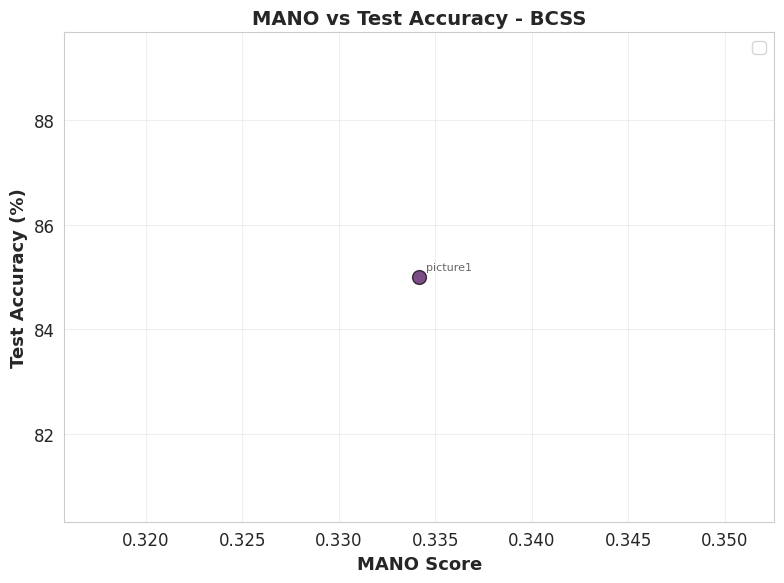

In [10]:
fig, ax = plot_mano_vs_accuracy(
        bcss_data,
        save_path='/home/claude/bcss_mano_plot.png',
        dataset_name='BCSS'
    )
plt.show()